In [6]:
import numpy as np
import tensorflow as tf
import datetime
import matplotlib.pyplot as plt
from matplotlib import rc 
from tensorflow.keras.callbacks import TensorBoard
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Input, Flatten, Activation
rc("font", family="Malgun Gothic") #폰트를 교체하는 명령어
plt.rcParams['axes.unicode_minus'] = False #마이너스 기호 깨짐 방지

x_train = np.random.rand(100, 1).astype(np.float32)
noise = np.random.normal(scale=0.1, size=(100, 1))
y_train = 3 * x_train + 2 + noise


In [3]:
c=tf.constant([[2,3],[6,7]])
print(tf.rank(c))
print(c)

tf.Tensor(2, shape=(), dtype=int32)
tf.Tensor(
[[2 3]
 [6 7]], shape=(2, 2), dtype=int32)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                      │ (None, 1)                   │               2 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

학습을 시작합니다...
학습 완료!
W= [[2.7772057]]
b= [2.1221611]


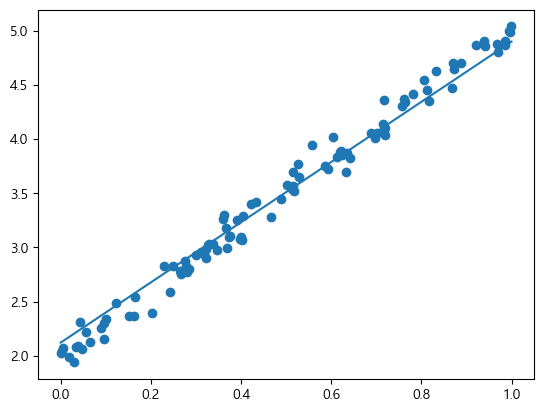

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6006 (pid 42240), started 2:15:12 ago. (Use '!kill 42240' to kill it.)

In [7]:
#토이 데이터셋 생성 (y = 3x + 2 + 잡음)
x_train = np.random.rand(100, 1).astype(np.float32) #astype() dtype을 변경함
#print(np.shape(x_train))
noise = np.random.normal(scale=0.1, size=(100, 1))
#print(np.shape(noise))
y_train = 3 * x_train + 2 + noise
plt.scatter(x_train, y_train)

#모델 만들기 (입력 1개 -> 출력 1개)
model = tf.keras.models.Sequential([
    tf.keras.layers.Dense(1, input_shape=(1,))
])
model.summary()

#학습 방법 설정 (SGD 옵티마이저, MSE 손실함수)
model.compile(optimizer='sgd', loss='mse') #Stochastic Gradient Descent(딥러닝에서 가장 기본)

# 로그를 저장할 폴더 이름 (현재 시간 포함해서 겹치지 않게 함)
log_dir = "logs/fit/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

# 텐서보드 콜백 생성
tensorboard_callback = TensorBoard(log_dir=log_dir, histogram_freq=1)

# 학습 시작 (callbacks 옵션에 추가!)
print("학습을 시작합니다...")
model.fit(x_train, y_train, 
          epochs=100, 
          callbacks=[tensorboard_callback],
          verbose=0) # 지저분한 로그 숨기기
print("학습 완료!")
layer0=model.layers[0]
W, b=layer0.get_weights()
print("W=", W)
print("b=", b)

x_line=np.linspace(0,1,10)
y_line=W[0]*x_line+b
plt.plot(x_line, y_line)
plt.show()

# 텐서보드 확장기능 로드(Magic Command)
%load_ext tensorboard

# 텐서보드 실행 (로그 폴더 지정)
%tensorboard --logdir logs/fit

#터미널에서 실행
#tensorboard --logdir logs/fit
#브라우저에서 http://localhost:6006 접속

In [9]:
d=tf.constant(['Hello'])
print(tf.rank(d))
print(d)

tf.Tensor(1, shape=(), dtype=int32)
tf.Tensor([b'Hello'], shape=(1,), dtype=string)


In [11]:
rand=tf.random.uniform([1], 0, 1) #shape:1, 0~1사이 값
print(rand.shape)
print(rand)

(1,)
tf.Tensor([0.40707517], shape=(1,), dtype=float32)


In [12]:
rand2=tf.random.normal([1,2], 0, 1) #mean:0, stddev=1
print(rand2.shape)
print(rand2)

(1, 2)
tf.Tensor([[ 0.83407223 -0.40934074]], shape=(1, 2), dtype=float32)


In [13]:
rand3=tf.random.normal(shape=(3,2), mean=1, stddev=3)
print(rand3.shape)
print(rand3)

(3, 2)
tf.Tensor(
[[ 4.8434362 -6.220443 ]
 [-0.4210136  1.8251   ]
 [-1.5097988 -3.5724077]], shape=(3, 2), dtype=float32)


In [14]:
a=tf.constant(3)
b=tf.constant(2)
print(tf.add(a,b))
print(a+b)

tf.Tensor(5, shape=(), dtype=int32)
tf.Tensor(5, shape=(), dtype=int32)


In [15]:
print(tf.subtract(a,b))
print(a-b)

tf.Tensor(1, shape=(), dtype=int32)
tf.Tensor(1, shape=(), dtype=int32)


In [16]:
print(tf.multiply(a,b))
print(a*b)

tf.Tensor(6, shape=(), dtype=int32)
tf.Tensor(6, shape=(), dtype=int32)


In [19]:
c=tf.add(a,b).numpy()
print(type(c))
print(c)

<class 'numpy.int32'>
5


In [21]:
c2=np.square(c, dtype=np.float32)
c2_tf=tf.convert_to_tensor(c2)
print(c2_tf)
print(type(c2_tf))

tf.Tensor(25.0, shape=(), dtype=float32)
<class 'tensorflow.python.framework.ops.EagerTensor'>


In [23]:
t=tf.constant([[1., 2., 3.], [5., 6., 7.]])
print(t.shape)
print(t.dtype)

(2, 3)
<dtype: 'float32'>


In [24]:
print(t[:,1:])


tf.Tensor(
[[2. 3.]
 [6. 7.]], shape=(2, 2), dtype=float32)


In [25]:
t[..., 1, tf.newaxis]

<tf.Tensor: shape=(2, 1), dtype=float32, numpy=
array([[2.],
       [6.]], dtype=float32)>

In [26]:
tf.square(t)

<tf.Tensor: shape=(2, 3), dtype=float32, numpy=
array([[ 1.,  4.,  9.],
       [25., 36., 49.]], dtype=float32)>

In [31]:
print(t)
t[...,2, tf.newaxis]

tf.Tensor(
[[1. 2. 3.]
 [5. 6. 7.]], shape=(2, 3), dtype=float32)


<tf.Tensor: shape=(2, 1), dtype=float32, numpy=
array([[3.],
       [7.]], dtype=float32)>

In [32]:
t @ tf.transpose(t)


<tf.Tensor: shape=(2, 2), dtype=float32, numpy=
array([[ 14.,  38.],
       [ 38., 110.]], dtype=float32)>

In [34]:
import timeit

In [35]:
@tf.function #Auto Graph
def my_function(x):
    return x**2 - 10*x + 3
print(my_function(2))
print(my_function(tf.constant(2)))

tf.Tensor(-13, shape=(), dtype=int32)
tf.Tensor(-13, shape=(), dtype=int32)


In [36]:
def my_function_(x):
    return x**2 - 10*x +3
print(my_function_(2))
print(my_function_(tf.constant(2)))

-13
tf.Tensor(-13, shape=(), dtype=int32)


In [39]:
tf_my_function=tf.function(my_function) #my_function함수를 graph로 변환함
print(tf_my_function)
print(tf_my_function(2))

tf.Tensor(-13, shape=(), dtype=int32)


In [46]:
tf_my_function(2)
tf_my_function.python_function(2)

<tf.Tensor: shape=(), dtype=int32, numpy=-13>